# 📈 Apple Stock Price Prediction Using Machine Learning

## Project Overview

The stock market is one of the most dynamic financial systems, where prices constantly change due to various factors such as company performance, investor sentiment, economic conditions, and global events. Predicting future stock prices is a challenging task because of this uncertainty, making it an interesting application of machine learning.

In this project, we use historical Apple stock market data to build machine learning models that predict the next trading day's closing price. The project follows a complete data science workflow, from data exploration and feature engineering to model training, evaluation, and performance comparison.

---

## Problem Statement

The goal of this project is to develop regression models capable of predicting Apple's next trading day's closing price using historical stock market data.

The project seeks to answer the following question:

> **Can historical stock prices and trading information be used to accurately predict the next trading day's closing price?**

---

## Project Objectives

The main objectives of this project are to:

- Understand the structure and characteristics of the dataset through Exploratory Data Analysis (EDA).
- Clean and prepare the data for modelling.
- Engineer meaningful features from historical stock prices and trading volume.
- Train and evaluate multiple machine learning regression models.
- Tune model hyperparameters to improve performance.
- Compare each model against a naive baseline using regression evaluation metrics.
- Identify the model that provides the best predictive performance.


In [2]:
#Installing the necessary libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)

from sklearn.inspection import permutation_importance
import shap

import kagglehub


In [3]:
!pip install statsmodels
!pip install shap
!pip install pandas_market_calendar
!pip install statsmodels
!pip install scikit-learn

ERROR: Could not find a version that satisfies the requirement pandas_market_calendar (from versions: none)
ERROR: No matching distribution found for pandas_market_calendar


In [4]:

data = kagglehub.dataset_download("camnugent/sandp500")
print(data)

C:\Users\GRACE\.cache\kagglehub\datasets\camnugent\sandp500\versions\4


In [5]:
#defining os
import os
#importing the all_stocks.csv file
df = pd.read_csv(os.path.join(data, "all_stocks_5yr.csv"))

In [6]:
print('First 5 rows of the dataset:')
print(df.head())


print("Last 5 rows of the dataset:")
print(df.tail())

First 5 rows of the dataset:
         date   open   high    low  close    volume Name
0  2013-02-08  15.07  15.12  14.63  14.75   8407500  AAL
1  2013-02-11  14.89  15.01  14.26  14.46   8882000  AAL
2  2013-02-12  14.45  14.51  14.10  14.27   8126000  AAL
3  2013-02-13  14.30  14.94  14.25  14.66  10259500  AAL
4  2013-02-14  14.94  14.96  13.16  13.99  31879900  AAL
Last 5 rows of the dataset:
              date   open   high    low  close   volume Name
619035  2018-02-01  76.84  78.27  76.69  77.82  2982259  ZTS
619036  2018-02-02  77.53  78.12  76.73  76.78  2595187  ZTS
619037  2018-02-05  76.64  76.92  73.18  73.83  2962031  ZTS
619038  2018-02-06  72.74  74.56  72.13  73.27  4924323  ZTS
619039  2018-02-07  72.70  75.00  72.69  73.86  4534912  ZTS


In [7]:
#shape of the dataset
print('Shape of the dataset:')
print(df.shape)

#columns in the dataset
print('Columns in the dataset:')
print(df.columns.tolist())

#data types of the columns
print('Data types of the columns:')
print(df.dtypes)


Shape of the dataset:
(619040, 7)
Columns in the dataset:
['date', 'open', 'high', 'low', 'close', 'volume', 'Name']
Data types of the columns:
date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
Name       object
dtype: object


In [8]:
#description of the dataset
print('Description of the dataset:')
print(df.describe())

#information about the dataset
print('Information about the dataset:')
print(df.info())

Description of the dataset:
                open           high            low          close  \
count  619029.000000  619032.000000  619032.000000  619040.000000   
mean       83.023334      83.778311      82.256096      83.043763   
std        97.378769      98.207519      96.507421      97.389748   
min         1.620000       1.690000       1.500000       1.590000   
25%        40.220000      40.620000      39.830000      40.245000   
50%        62.590000      63.150000      62.020000      62.620000   
75%        94.370000      95.180000      93.540000      94.410000   
max      2044.000000    2067.990000    2035.110000    2049.000000   

             volume  
count  6.190400e+05  
mean   4.321823e+06  
std    8.693610e+06  
min    0.000000e+00  
25%    1.070320e+06  
50%    2.082094e+06  
75%    4.284509e+06  
max    6.182376e+08  
Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column

In [9]:
#date range of the dataset
print('Date range of the dataset:') 
print(df['date'].min(), 'to', df['date'].max())

Date range of the dataset:
2013-02-08 to 2018-02-07


In [10]:
df['Name'].unique()

array(['AAL', 'AAPL', 'AAP', 'ABBV', 'ABC', 'ABT', 'ACN', 'ADBE', 'ADI',
       'ADM', 'ADP', 'ADSK', 'ADS', 'AEE', 'AEP', 'AES', 'AET', 'AFL',
       'AGN', 'AIG', 'AIV', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALK',
       'ALLE', 'ALL', 'ALXN', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMG', 'AMP',
       'AMT', 'AMZN', 'ANDV', 'ANSS', 'ANTM', 'AON', 'AOS', 'APA', 'APC',
       'APD', 'APH', 'APTV', 'ARE', 'ARNC', 'ATVI', 'AVB', 'AVGO', 'AVY',
       'AWK', 'AXP', 'AYI', 'AZO', 'A', 'BAC', 'BAX', 'BA', 'BBT', 'BBY',
       'BDX', 'BEN', 'BF.B', 'BHF', 'BHGE', 'BIIB', 'BK', 'BLK', 'BLL',
       'BMY', 'BRK.B', 'BSX', 'BWA', 'BXP', 'CAG', 'CAH', 'CAT', 'CA',
       'CBG', 'CBOE', 'CBS', 'CB', 'CCI', 'CCL', 'CDNS', 'CELG', 'CERN',
       'CFG', 'CF', 'CHD', 'CHK', 'CHRW', 'CHTR', 'CINF', 'CI', 'CLX',
       'CL', 'CMA', 'CMCSA', 'CME', 'CMG', 'CMI', 'CMS', 'CNC', 'CNP',
       'COF', 'COG', 'COL', 'COO', 'COP', 'COST', 'COTY', 'CPB', 'CRM',
       'CSCO', 'CSRA', 'CSX', 'CTAS', 'CTL', 'CTSH', 'CTXS

In [11]:
apple_df = df[df['Name'] == 'AAPL']

In [12]:
apple_df.shape

(1259, 7)

In [13]:
# Check for working days in the dataset and the expected number of trading days
apple_df = apple_df.sort_values('date').reset_index(drop=True)

import pandas_market_calendars as mcal
nyse = mcal.get_calendar('NYSE')
schedule = nyse.schedule(
    start_date = apple_df['date'].min(),
    end_date = apple_df['date'].max()
)

expected_dates = schedule.index.normalize()

actual_days = pd.to_datetime(apple_df['date']).dt.normalize()

missing_dates = expected_dates.difference(actual_days)
print('Missing dates in the dataset:', len(missing_dates))

print(missing_dates)

Missing dates in the dataset: 0
DatetimeIndex([], dtype='datetime64[ns]', freq=None)


In [14]:
#zooming to check for split window for apple in june,2014
split_period = (apple_df['date'] >= '2014-06-01') & (apple_df['date'] <= '2014-06-30')   
print(apple_df.loc[split_period, ['date','close']])

           date    close
329  2014-06-02  89.8071
330  2014-06-03  91.0771
331  2014-06-04  92.1171
332  2014-06-05  92.4785
333  2014-06-06  92.2242
334  2014-06-09  93.7000
335  2014-06-10  94.2500
336  2014-06-11  93.8600
337  2014-06-12  92.2900
338  2014-06-13  91.2800
339  2014-06-16  92.2000
340  2014-06-17  92.0800
341  2014-06-18  92.1800
342  2014-06-19  91.8600
343  2014-06-20  90.9100
344  2014-06-23  90.8300
345  2014-06-24  90.2800
346  2014-06-25  90.3600
347  2014-06-26  90.9000
348  2014-06-27  91.9800
349  2014-06-30  92.9300


In [15]:
#checking the shape of the split_period
split_period.shape

(1259,)

In [16]:
#duplicates in the dataset
print('Number of duplicate rows in the dataset:')
print(apple_df.duplicated().sum())
print('='*70)


#NaN value and Negative values in volume column
print('Number of NaN values in the volume column:')
print(apple_df['volume'].isna().sum())

print('='*70)
print('Number of negative values in the volume column:')
print((apple_df['volume'] < 0).sum())

Number of duplicate rows in the dataset:
0
Number of NaN values in the volume column:
0
Number of negative values in the volume column:
0


In [17]:
#Checking for invalid high/low/close/open values
bad = apple_df[
    (apple_df['high'] < apple_df['low']) |
    (apple_df['high'] < apple_df['close']) |
    (apple_df['high'] < apple_df['open']) |
    (apple_df['low'] > apple_df['close']) |
    (apple_df['low'] > apple_df['open'])
]

print('Number of rows with invalid high/low/close/open values:')
print(len(bad))

Number of rows with invalid high/low/close/open values:
0


In [18]:
apple_df.head(10)

,date,open,high,low,close,volume,Name
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL
5,2013-02-15,66.9785,67.1656,65.7028,65.7371,97924631,AAPL
6,2013-02-19,65.8714,66.1042,64.8356,65.7128,108854046,AAPL
7,2013-02-20,65.3842,65.3842,64.1142,64.1214,118891367,AAPL
8,2013-02-21,63.7142,64.1671,63.2599,63.7228,111596821,AAPL
9,2013-02-22,64.1785,64.5142,63.7999,64.4014,82583823,AAPL


## Exploratory Data Analysis (EDA)

In [19]:
#lagging the close price for 1day to 5 days
apple_df['close_lag_1'] = apple_df['close'].shift(1)
apple_df['close_lag_2'] = apple_df['close'].shift(2)
apple_df['close_lag_3'] = apple_df['close'].shift(3)
apple_df['close_lag_4'] = apple_df['close'].shift(4)
apple_df['close_lag_5'] = apple_df['close'].shift(5)

#Rolling means for 5,10 and 20days
apple_df['ma'] = apple_df['close'].rolling(window=5).mean()
apple_df['ma_10'] = apple_df['close'].rolling(window=10).mean()
apple_df['ma_20'] = apple_df['close'].rolling(window=20).mean()

#rolling std for 5 days
apple_df['rolling_std_5'] = apple_df['close'].rolling(window=5).std()

#Day-over-day percentage change in close price adn volume
apple_df['daily_return'] = apple_df['close'].pct_change() * 100
apple_df['volume_change'] = apple_df['volume'].pct_change() * 100

#intra-day range
apple_df['high_low_diff'] = apple_df['high'] - apple_df['low']
apple_df['open_close_diff'] = apple_df['open'] - apple_df['close']

#Target variable: next day's close price
apple_df['target'] = apple_df['close'].shift(-1)


In [20]:
apple_df.head(10)

,date,open,high,low,close,volume,Name,close_lag_1,close_lag_2,close_lag_3,...,close_lag_5,ma,ma_10,ma_20,rolling_std_5,daily_return,volume_change,high_low_diff,open_close_diff,target
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.5086,-0.1400,68.5614
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL,67.8542,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.042235,-18.422762,1.6700,-0.4900,66.8428
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL,68.5614,67.8542,NaN,...,NaN,NaN,NaN,NaN,NaN,-2.506658,17.670340,2.0909,1.6586,66.7156
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL,66.8428,68.5614,67.8542,...,NaN,NaN,NaN,NaN,NaN,-0.190297,-21.805642,1.4886,0.0286,66.6556
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL,66.7156,66.8428,68.5614,...,NaN,67.32592,NaN,NaN,0.845682,-0.089934,-25.195703,1.0886,-0.2957,65.7371
5,2013-02-15,66.9785,67.1656,65.7028,65.7371,97924631,AAPL,66.6556,66.7156,66.8428,...,67.8542,66.90250,NaN,NaN,1.025861,-1.377979,10.264119,1.4628,1.2414,65.7128
6,2013-02-19,65.8714,66.1042,64.8356,65.7128,108854046,AAPL,65.7371,66.6556,66.7156,...,68.5614,66.33278,NaN,NaN,0.559038,-0.036965,11.161048,1.2686,0.1586,64.1214
7,2013-02-20,65.3842,65.3842,64.1142,64.1214,118891367,AAPL,65.7128,65.7371,66.6556,...,66.8428,65.78850,NaN,NaN,1.048686,-2.421750,9.220898,1.2700,1.2628,63.7228
8,2013-02-21,63.7142,64.1671,63.2599,63.7228,111596821,AAPL,64.1214,65.7128,65.7371,...,66.7156,65.18994,NaN,NaN,1.226296,-0.621633,-6.135472,0.9072,-0.0086,64.4014
9,2013-02-22,64.1785,64.5142,63.7999,64.4014,82583823,AAPL,63.7228,64.1214,65.7128,...,66.6556,64.73910,66.03251,NaN,0.931740,1.064925,-25.998051,0.7143,-0.2229,63.2571


In [46]:
#check for NaN values in the dataset
print('='*70)
print("the shape before dropping the na values is ", apple_df.shape)

print('='*70)
print(apple_df.isna().sum())

the shape before dropping the na values is  (1239, 21)
date               0
open               0
high               0
low                0
close              0
volume             0
Name               0
close_lag_1        0
close_lag_2        0
close_lag_3        0
close_lag_4        0
close_lag_5        0
ma                 0
ma_10              0
ma_20              0
rolling_std_5      0
daily_return       0
volume_change      0
high_low_diff      0
open_close_diff    0
target             0
dtype: int64


In [ ]:
# Drop rows with NaN values
apple_df = apple_df.dropna().reset_index(drop=True)
print('the shape after dropping the na values is ', apple_df.shape)

the shape after dropping the na values is  (1239, 21)


In [23]:
#checking for NaN values after dropping them
apple_df.isna().sum()

date               0
open               0
high               0
low                0
close              0
volume             0
Name               0
close_lag_1        0
close_lag_2        0
close_lag_3        0
close_lag_4        0
close_lag_5        0
ma                 0
ma_10              0
ma_20              0
rolling_std_5      0
daily_return       0
volume_change      0
high_low_diff      0
open_close_diff    0
target             0
dtype: int64

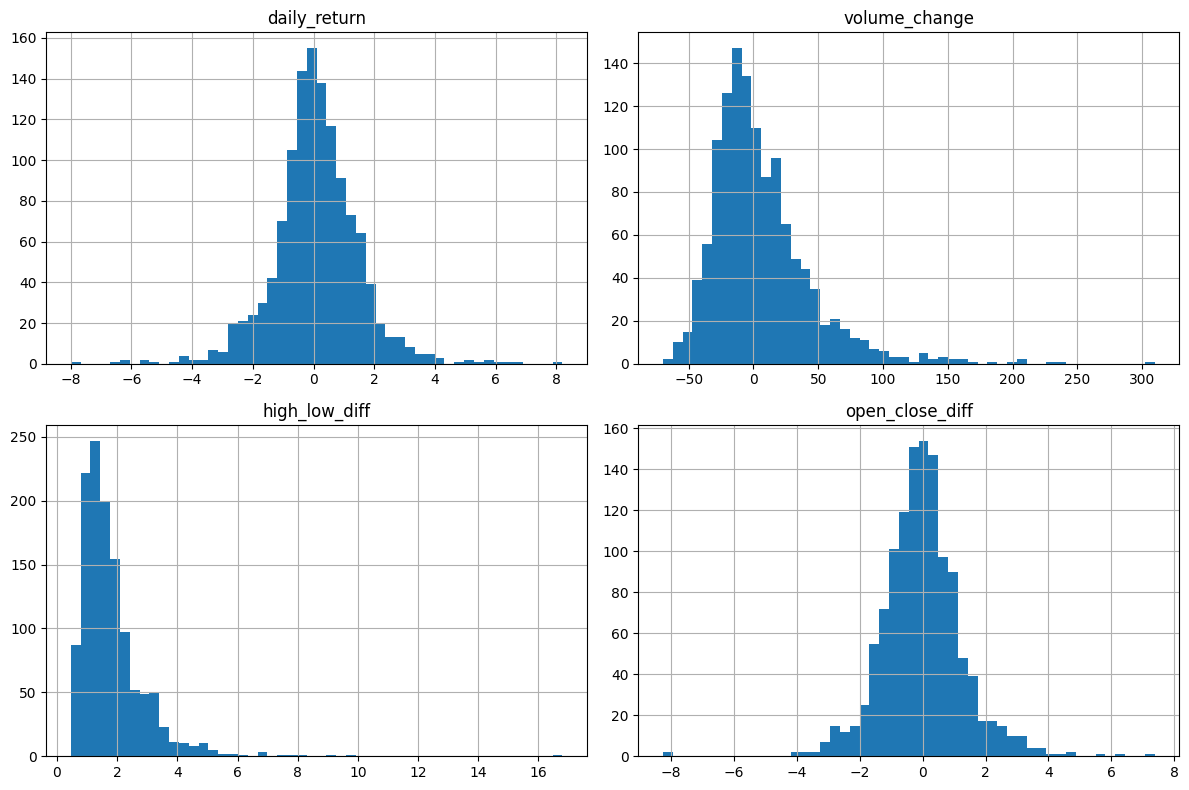

,daily_return,volume_change,high_low_diff,open_close_diff
count,1239.000000,1239.000000,1239.000000,1239.000000
mean,0.089290,5.866731,1.813038,-0.019287
std,1.456140,39.151957,1.122199,1.284736
min,-7.992722,-69.897398,0.460000,-8.250000
25%,-0.626021,-19.254274,1.120000,-0.752600
50%,0.053552,-2.653332,1.530000,-0.046200
75%,0.862457,21.544882,2.175000,0.679250
max,8.198180,309.533213,16.800000,7.370000


In [47]:
# Plot histograms for the selected columns
cols = ['daily_return', 'volume_change', 'high_low_diff', 'open_close_diff']

apple_df[cols].hist(bins=50, figsize=(12, 8))
plt.tight_layout()
plt.show()

apple_df[cols].describe()

In [48]:
#checking for skewness and kurtosis of the features
#skewness is a measure of the asymmetry of the probability distribution of a real-valued random variable about its mean. A positive skew indicates that the tail on the right side of the distribution is longer or fatter than the left side, while a negative skew indicates that the tail on the left side is longer or fatter than the right side.
#kurtosis is a measure of the "tailedness" of the probability distribution of a real-valued random variable. A high kurtosis indicates that the distribution has heavy tails or outliers, while a low kurtosis indicates that the distribution has light tails or lacks outliers.

print('='*70)

print('skewness and kurtosis of the features:')
print(apple_df[cols].agg(['skew', 'kurtosis']).T)
print('='*70)

skewness and kurtosis of the features:
                     skew   kurtosis
daily_return     0.007880   3.901822
volume_change    1.957003   7.347503
high_low_diff    3.731000  31.596001
open_close_diff  0.104227   4.465565


In [49]:
#adfuller test for stationarity,adfuller is a statistical test used to determine whether a time series is stationary or not. A stationary time series has a constant mean and variance over time, while a non-stationary time series has a changing mean and/or variance over time. The adfuller test checks for the presence of a unit root in the time series, which indicates non-stationarity. The null hypothesis of the test is that the time series has a unit root (i.e., it is non-stationary), while the alternative hypothesis is that the time series does not have a unit root (i.e., it is stationary). The test returns a p-value, which can be used to determine whether to reject or fail to reject the null hypothesis.
from statsmodels.tsa.stattools import adfuller

#raw close evaluation for stationarity
result = adfuller(apple_df['close'].dropna())

#daily return evaluation for stationarity
result_ret = adfuller(apple_df['daily_return'].dropna())
print('='*70)
print('p-value for raw close price:', result[1])
print('p-value for daily return:', result_ret[1])
print('='*70)

p-value for raw close price: 0.8307516467764863
p-value for daily return: 0.0


Text(0.5, 1.0, 'PACF of Daily Return')

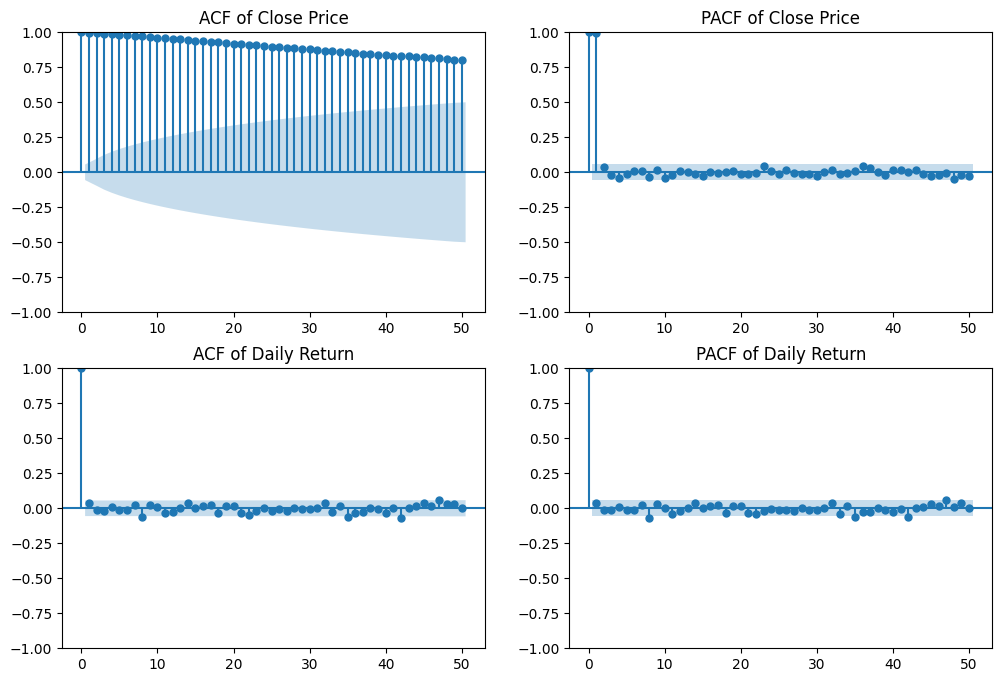

In [50]:
#acf and pacf plots for raw close price and daily return

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig,axes = plt.subplots(2,2,figsize=(12,8))

#close price ACF and PACF
plot_acf(apple_df['close'], ax=axes[0,0], lags=50)
axes[0,0].set_title('ACF of Close Price')

plot_pacf(apple_df['close'], ax=axes[0,1], lags=50)
axes[0,1].set_title('PACF of Close Price')


#daily return ACF and PACF
plot_acf(apple_df['daily_return'], ax=axes[1,0], lags=50)
axes[1,0].set_title('ACF of Daily Return')

plot_pacf(apple_df['daily_return'], ax=axes[1,1], lags=50)
axes[1,1].set_title('PACF of Daily Return')

In [28]:
apple_df.head(10)

,date,open,high,low,close,volume,Name,close_lag_1,close_lag_2,close_lag_3,...,close_lag_5,ma,ma_10,ma_20,rolling_std_5,daily_return,volume_change,high_low_diff,open_close_diff,target
0,2013-03-08,61.3999,62.2042,61.2299,61.6742,97854442,AAPL,61.5117,60.8088,61.5919,...,61.4957,61.11874,62.10520,64.068855,0.710394,0.264177,-16.358607,0.9743,-0.2743,62.5528
1,2013-03-11,61.3928,62.7157,60.7342,62.5528,118272126,AAPL,61.6742,61.5117,60.8088,...,60.0071,61.62788,62.03477,63.803785,0.621150,1.424583,20.865362,1.9815,-1.1600,61.2042
2,2013-03-12,62.2285,62.6971,61.0814,61.2042,116268341,AAPL,62.5528,61.6742,61.5117,...,61.5919,61.55034,61.74134,63.435925,0.650280,-2.155939,-1.694216,1.6157,1.0243,61.1928
3,2013-03-13,61.2071,62.0714,60.7657,61.1928,101369051,AAPL,61.2042,62.5528,61.6742,...,60.8088,61.62714,61.50963,63.153425,0.556758,-0.018626,-12.814572,1.3057,0.0143,61.7857
4,2013-03-14,61.8328,62.0914,61.4928,61.7857,75834906,AAPL,61.1928,61.2042,62.5528,...,61.5117,61.68194,61.38249,62.906930,0.556039,0.968905,-25.189291,0.5986,0.0471,63.3799
5,2013-03-15,62.5614,63.4614,62.4642,63.3799,160710606,AAPL,61.7857,61.1928,61.2042,...,61.6742,62.02308,61.57091,62.743145,0.940458,2.580209,111.921679,0.9972,-0.8185,65.1028
6,2013-03-18,63.0642,65.3514,63.0285,65.1028,150441144,AAPL,63.3799,61.7857,61.1928,...,62.5528,62.53308,62.08048,62.711430,1.691258,2.718370,-6.390034,2.3229,-2.0386,64.9271
7,2013-03-19,65.6428,65.8528,64.0714,64.9271,131531708,AAPL,65.1028,63.3799,61.7857,...,61.2042,63.27766,62.41400,62.672145,1.777275,-0.269881,-12.569325,1.7814,0.7157,64.5828
8,2013-03-20,65.3456,65.3756,64.2271,64.5828,77016849,AAPL,64.9271,65.1028,63.3799,...,61.1928,63.95566,62.79140,62.695215,1.386827,-0.530287,-41.446173,1.1485,0.7628,64.6756
9,2013-03-21,64.3171,65.4256,64.2999,64.6756,95493524,AAPL,64.5828,64.9271,65.1028,...,61.7857,64.53364,63.10779,62.742855,0.676838,0.143692,23.990432,1.1257,-0.3585,65.9871


In [29]:
feature_cols = ['close_lag_1', 'close_lag_2', 'close_lag_3', 'close_lag_4', 'close_lag_5',
                'ma', 'ma_10', 'ma_20', 'rolling_std_5', 'daily_return', 'volume_change', 'high_low_diff', 'open_close_diff']


corr= apple_df[feature_cols + ['target']].corr()

In [30]:
print('='*70)
print('Correlation matrix of features and target variable:')
print(corr['target'].sort_values(ascending=False))
print('='*70)

Correlation matrix of features and target variable:
target             1.000000
close_lag_1        0.997226
ma                 0.997023
close_lag_2        0.995911
ma_10              0.994815
close_lag_3        0.994627
close_lag_4        0.993305
close_lag_5        0.991950
ma_20              0.990514
high_low_diff      0.271806
rolling_std_5      0.250872
daily_return       0.015257
volume_change      0.012861
open_close_diff   -0.023187
Name: target, dtype: float64


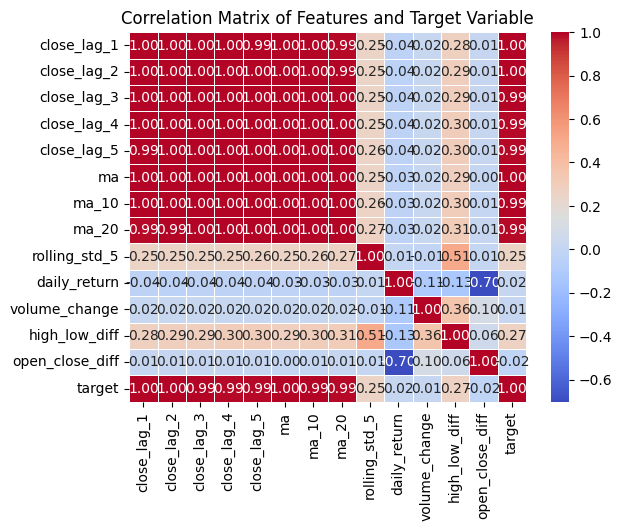

In [31]:
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Features and Target Variable')
plt.show()

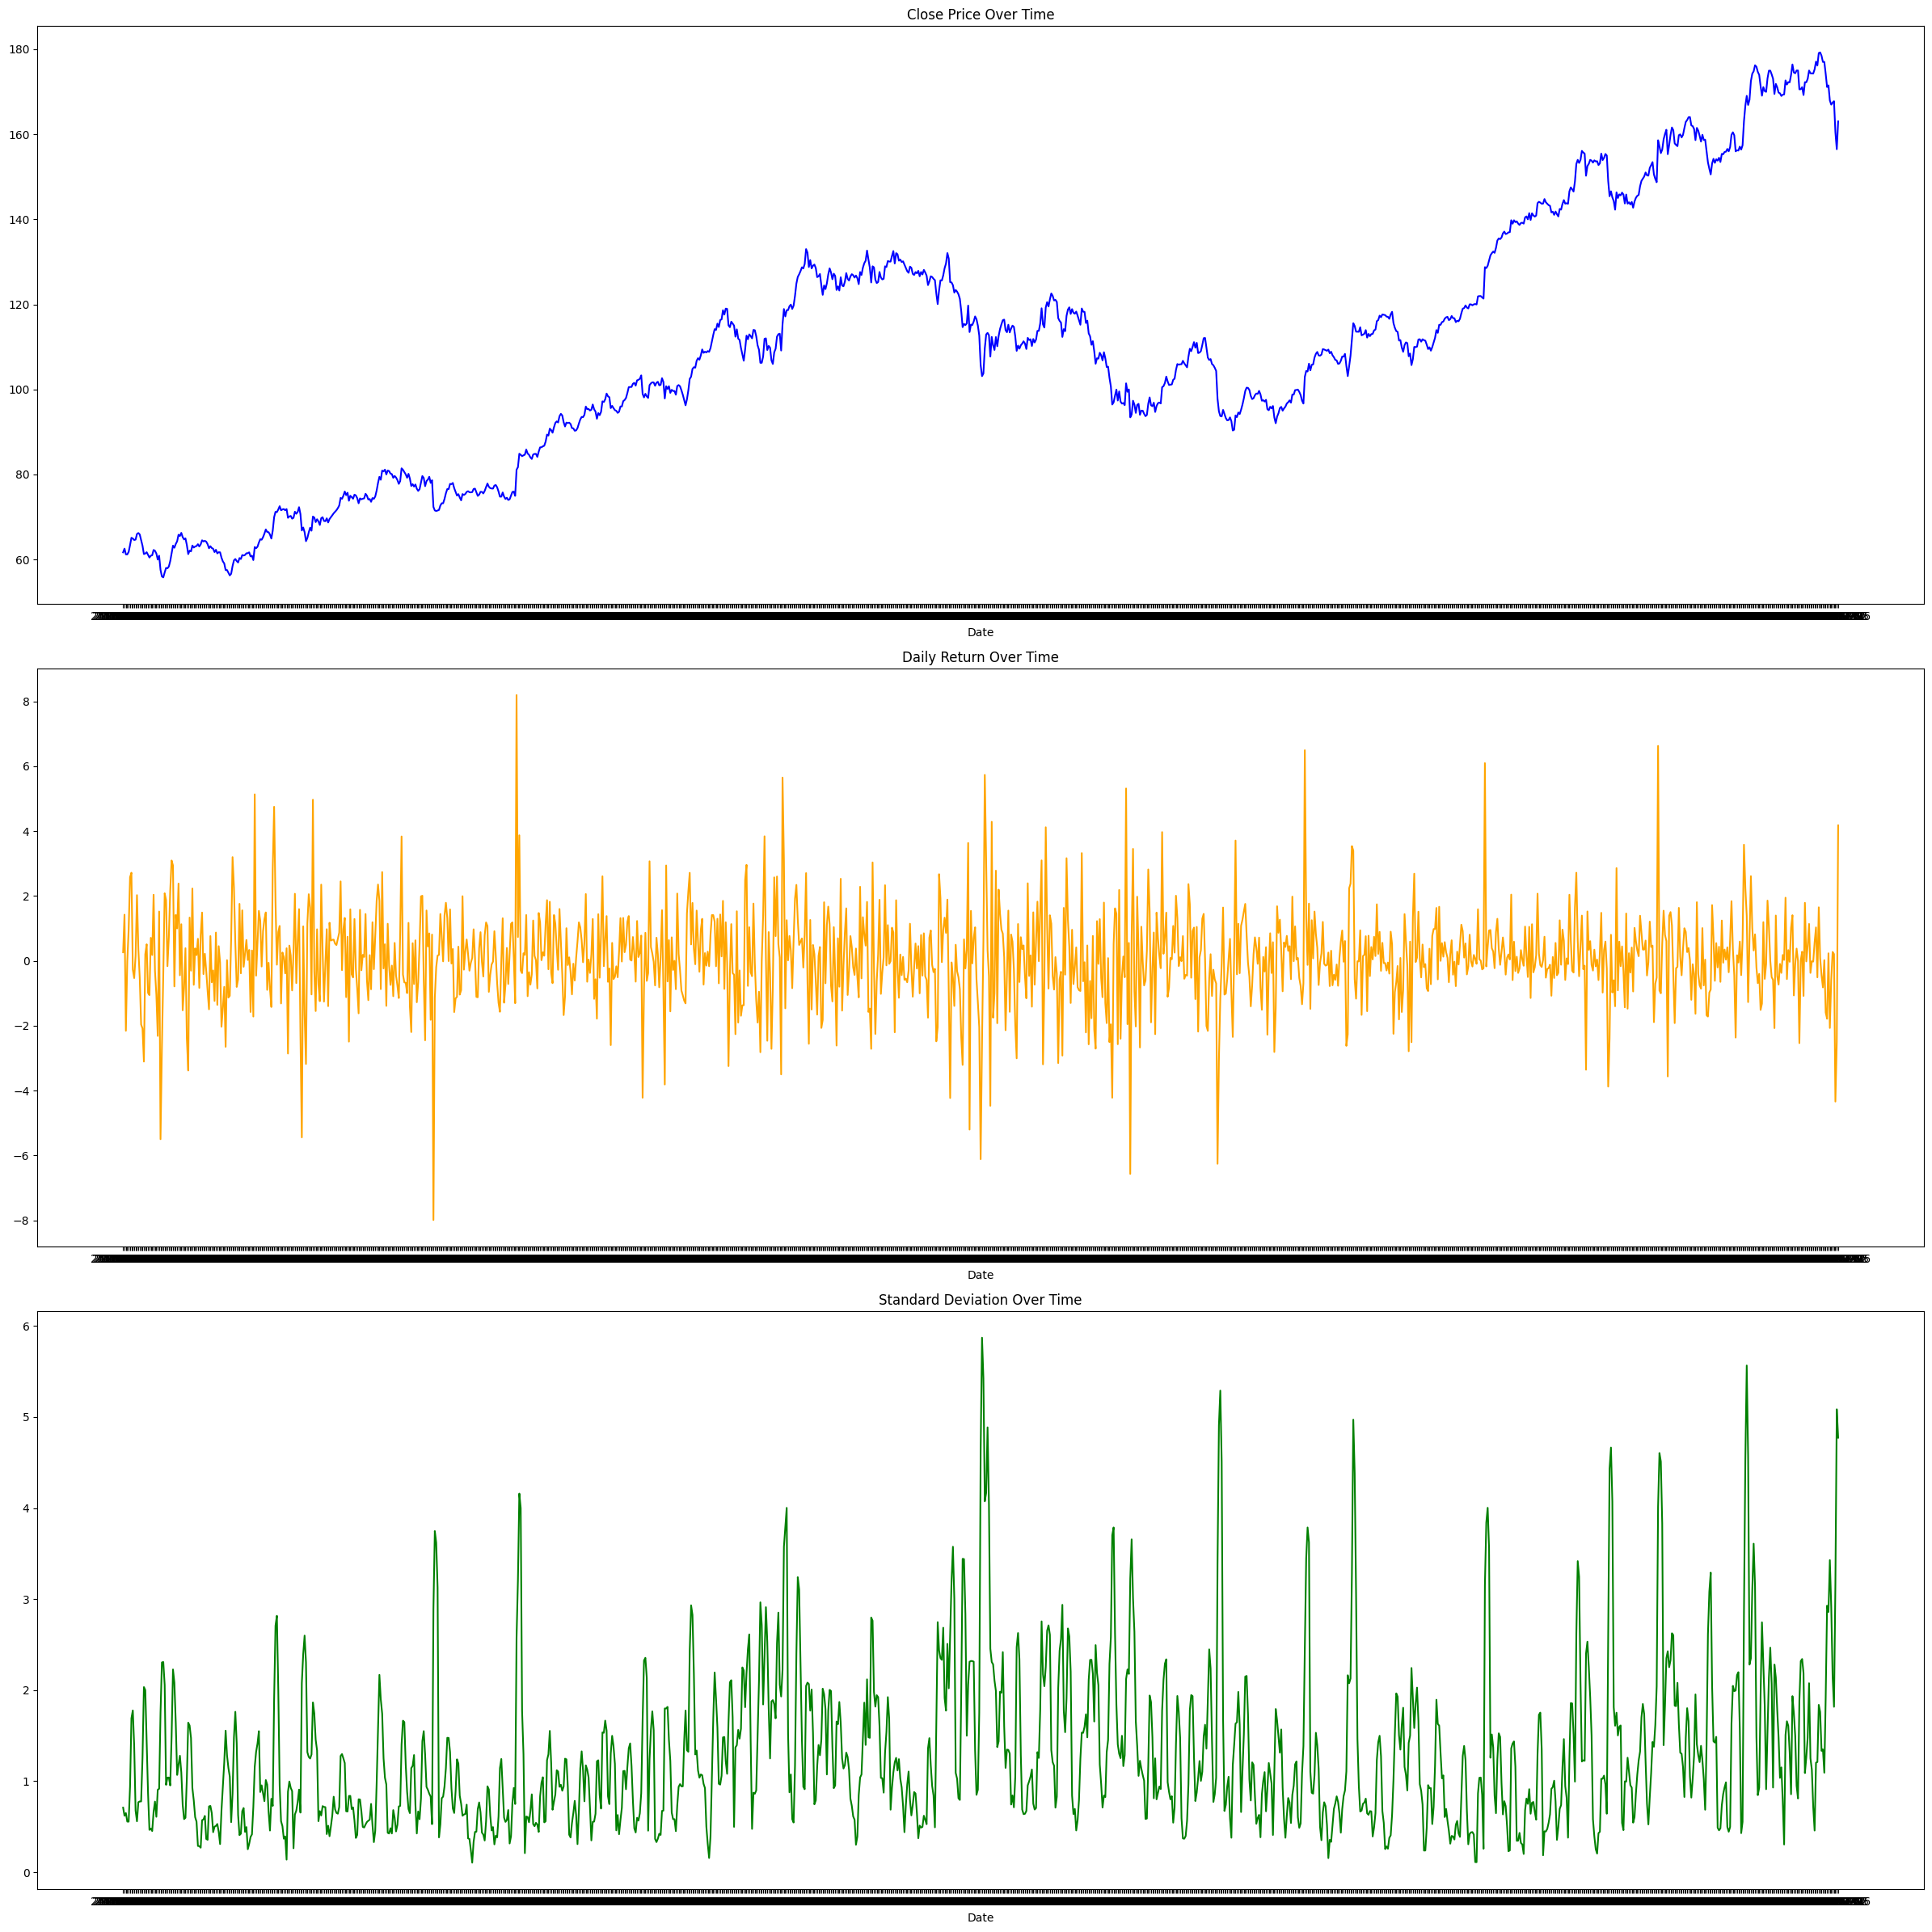

In [51]:
#plotting close price, daily return, and standard deviation over time
fig, axes = plt.subplots(3,1 , figsize=(24, 24))

#close price over time
axes[0].plot(apple_df['date'], apple_df['close'], label='Close Price', color='blue')
axes[0].set_title('Close Price Over Time')
axes[0].set_xlabel('Date')

#daily return over time
axes[1].plot(apple_df['date'], apple_df['daily_return'], label='Daily Return', color='orange')
axes[1].set_title('Daily Return Over Time')
axes[1].set_xlabel('Date')

#std deviation over time
axes[2].plot(apple_df['date'], apple_df['rolling_std_5'], label='Standard Deviation', color='green')
axes[2].set_title('Standard Deviation Over Time')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

In [33]:
#sorting the data by date and resetting the index
apple_df = apple_df.sort_values('date').reset_index(drop=True)

split_index = int(len(apple_df) * 0.8)
train = apple_df.iloc[:split_index]
test = apple_df.iloc[split_index:]

print('='*70)
print('Shape of training set:', train.shape)
print('Shape of testing set:', test.shape)
print("Train", train['date'].min(), "→", train['date'].max())
print("Test", test['date'].min(), "→", test['date'].max())
print('='*70)

Shape of training set: (991, 21)
Shape of testing set: (248, 21)
Train 2013-03-08 → 2017-02-10
Test 2017-02-13 → 2018-02-06


In [34]:
#features and target variable for training and testing sets

feature_cols = ['close_lag_1', 'close_lag_2', 'close_lag_3', 'close_lag_4', 'close_lag_5',
                'ma', 'ma_10', 'ma_20', 'rolling_std_5', 'daily_return', 'volume_change', 'high_low_diff', 'open_close_diff']
target_col = 'target'
x_train, y_train = train[feature_cols], train[target_col]
x_test, y_test = test[feature_cols], test[target_col]

In [35]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train) 
x_test_scaled = scaler.transform(x_test)

Naive Baseline Model Performance:
Mean Squared Error (MSE): 3.5802
Mean Absolute Error (MAE): 1.3072
Mean Absolute Percentage Error (MAPE): 0.0083
R-squared (R2): 0.9752


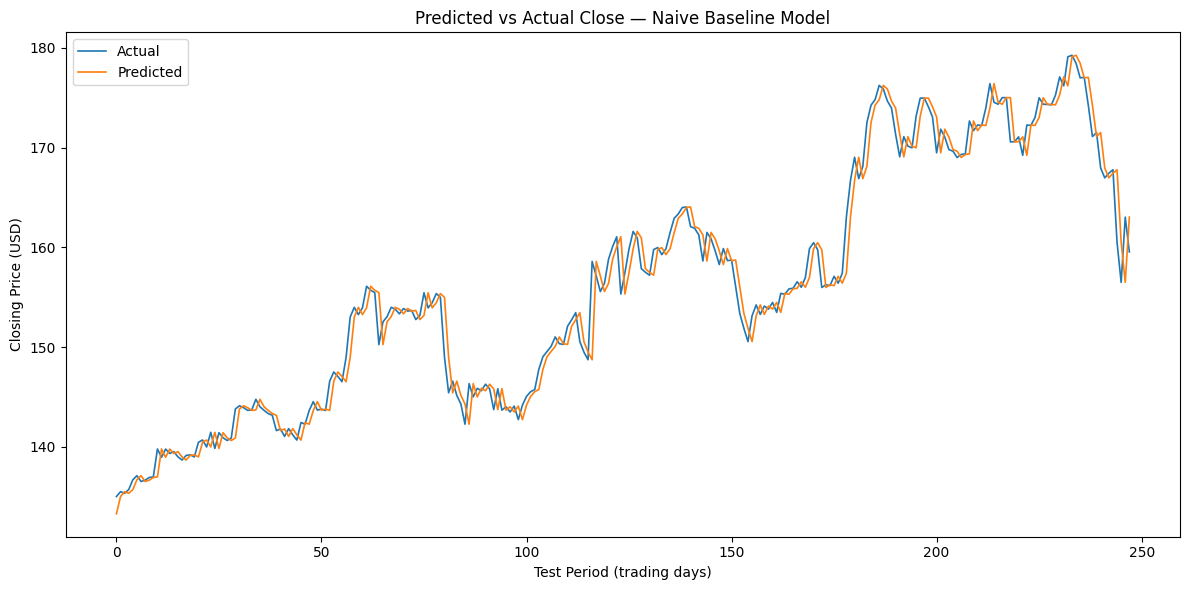

In [36]:
#normal baseline model

#Naive baseline model: predicting the next day's close price as today's close price
naive_predictions = test['close'].values
actual = test['target'].values


from choix import rmse
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score,root_mean_squared_error

mse = mean_squared_error(actual, naive_predictions)
mae = mean_absolute_error(actual, naive_predictions)
mape = mean_absolute_percentage_error(actual, naive_predictions)
r2 = r2_score(actual, naive_predictions)

print('='*70)
print('Naive Baseline Model Performance:')
print('Mean Squared Error (MSE):', round(mse, 4))
print('Mean Absolute Error (MAE):', round(mae, 4))
print('Mean Absolute Percentage Error (MAPE):', round(mape, 4))
print('R-squared (R2):', round(r2, 4))
print('='*70)


#plotting the naive baseline model predictions against the actual values
plt.figure(figsize=(12, 6))
plt.plot(actual, label="Actual", linewidth=1.2)
plt.plot(naive_predictions, label="Predicted", linewidth=1.2)
plt.title("Predicted vs Actual Close — Naive Baseline Model")
plt.xlabel("Test Period (trading days)")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

Linear Regression Model Performance:
Mean Squared Error (MSE): 3.6702
R-squared Score: 0.9746


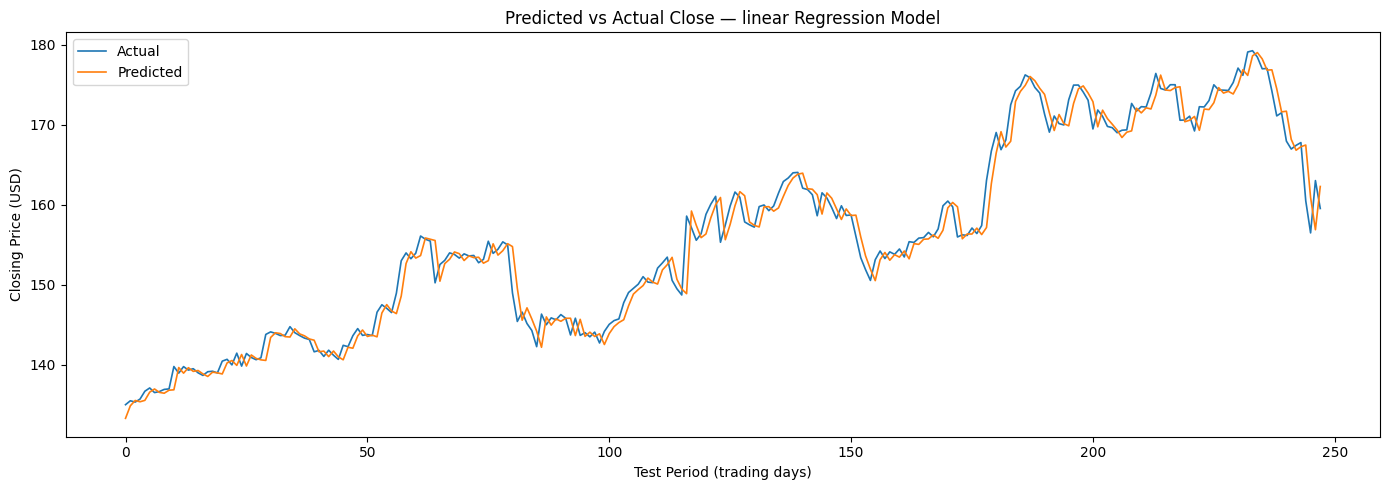

In [37]:
#linear regression model
lr_model = LinearRegression()
lr_model.fit(x_train_scaled, y_train)

lr_predictions = lr_model.predict(x_test_scaled)

print('='*70)
print('Linear Regression Model Performance:')
print('Mean Squared Error (MSE):', round(mean_squared_error(y_test, lr_predictions), 4))
print('R-squared Score:', round(r2_score(y_test, lr_predictions), 4))
print('='*70)

# plotting the actual vs predicted values for linear regression model
plt.figure(figsize=(14, 5))
plt.plot(actual, label="Actual", linewidth=1.2)
plt.plot(lr_predictions, label="Predicted", linewidth=1.2)
plt.title("Predicted vs Actual Close — linear Regression Model")
plt.xlabel("Test Period (trading days)")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

Ridge Regression Model Performance:
Mean Squared Error (MSE): 4.1237
Mean Absolute Error (MAE): 1.4179
R-squared (R2): 0.9715


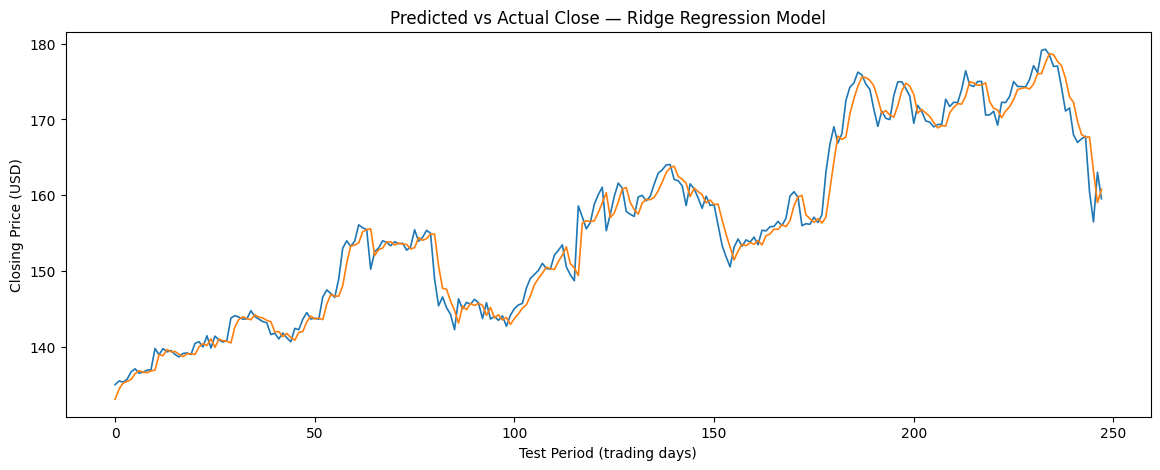

In [52]:
#ridge regression model
from matplotlib.pyplot import plot
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(x_train_scaled, y_train)

ridge_predictions = ridge_model.predict(x_test_scaled)

ridge_mse = mean_squared_error(y_test, ridge_predictions)
ridge_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_r2 = r2_score(y_test, ridge_predictions)


print('='*70)
print('Ridge Regression Model Performance:')
print('Mean Squared Error (MSE):', round(ridge_mse, 4))
print('Mean Absolute Error (MAE):', round(ridge_mae, 4))
print('R-squared (R2):', round(ridge_r2, 4))
print('='*70)

#plotting the actual vs predicted values for ridge regression model
plt.figure(figsize=(14, 5))
plt.plot(actual, label="Actual", linewidth=1.2)
plt.plot(ridge_predictions, label="Predicted", linewidth=1.2)
plt.title("Predicted vs Actual Close — Ridge Regression Model")
plt.xlabel("Test Period (trading days)")
plt.ylabel("Closing Price (USD)")   
plt.show()


Lasso Regression Model Performance:
Mean Squared Error (MSE): 4.3832
Mean Absolute Error (MAE): 1.469
R-squared (R2): 0.9697


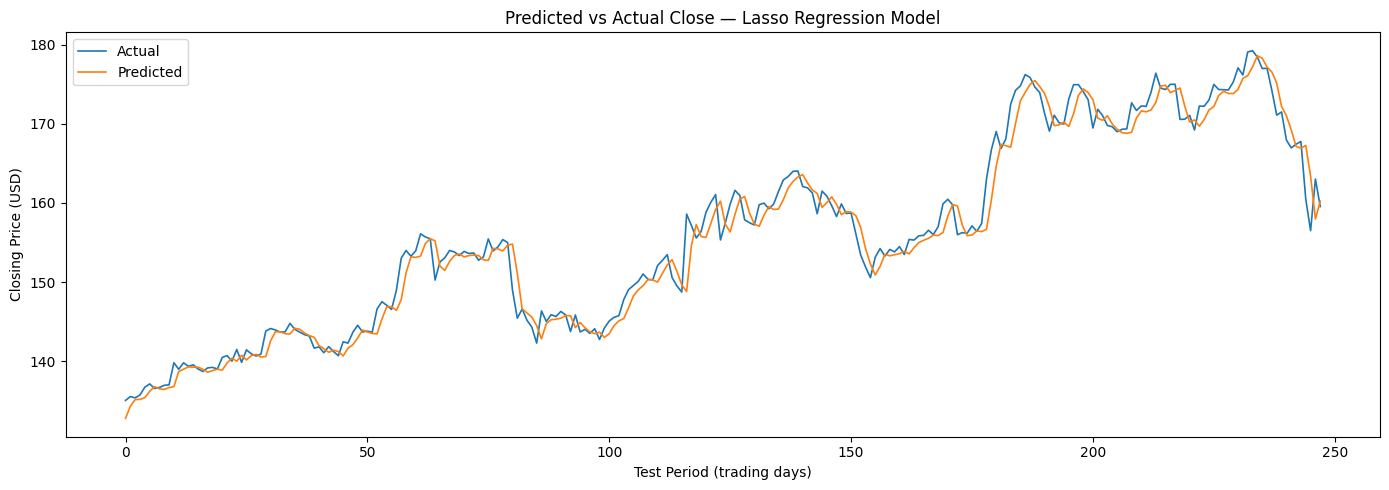

In [53]:
#lasso regression model
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=0.1)

lasso_model.fit(x_train_scaled, y_train)
lasso_predictions = lasso_model.predict(x_test_scaled)
lasso_mse = mean_squared_error(y_test, lasso_predictions)
lasso_mae = mean_absolute_error(y_test, lasso_predictions)
lasso_r2 = r2_score(y_test, lasso_predictions)

print('='*70)
print('Lasso Regression Model Performance:')
print('Mean Squared Error (MSE):', round(lasso_mse, 4))
print('Mean Absolute Error (MAE):', round(lasso_mae, 4))
print('R-squared (R2):', round(lasso_r2, 4))
print('='*70)


plt.figure(figsize=(14, 5))
plt.plot(actual, label="Actual", linewidth=1.2)
plt.plot(lasso_predictions, label="Predicted", linewidth=1.2)
plt.title("Predicted vs Actual Close — Lasso Regression Model")
plt.xlabel("Test Period (trading days)")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

Random Forest Model Performance:
Mean Squared Error (MSE): 817.5848
Mean Absolute Error (MAE): 25.9349
R-squared (R2): -4.655


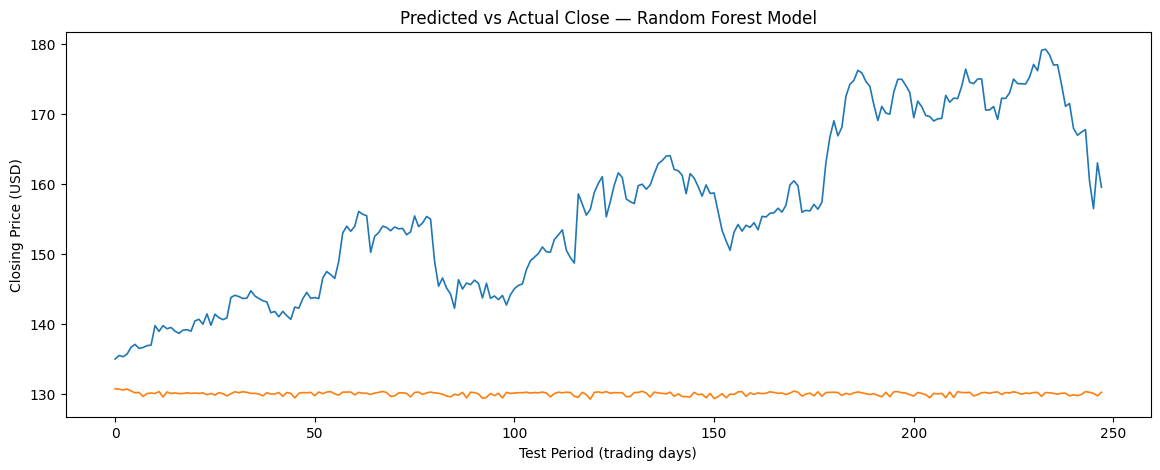

In [54]:
#Random Forest Regressor model
from sklearn.ensemble import RandomForestRegressor


rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train_scaled, y_train)

rf_predictions = rf.predict(x_test_scaled)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print('='*70)
print('Random Forest Model Performance:')
print('Mean Squared Error (MSE):', round(rf_mse, 4))
print('Mean Absolute Error (MAE):', round(rf_mae, 4))
print('R-squared (R2):', round(rf_r2, 4))
print('='*70)

#plotting the actual vs predicted values for random forest model
plt.figure(figsize=(14, 5))
plt.plot(actual, label="Actual", linewidth=1.2)
plt.plot(rf_predictions, label="Predicted", linewidth=1.2)
plt.title("Predicted vs Actual Close — Random Forest Model")
plt.xlabel("Test Period (trading days)")
plt.ylabel("Closing Price (USD)")
plt.show()

XGBoost Model Performance:
Mean Squared Error (MSE): 819.3434
Mean Absolute Error (MAE): 25.9129
R-squared (R2): -4.6671


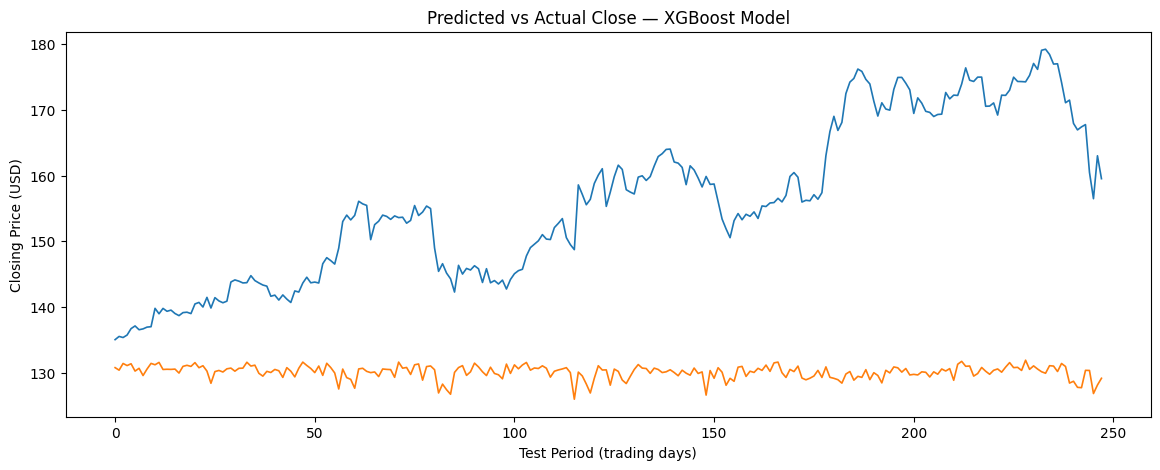

In [55]:
#XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(x_train_scaled, y_train)

xgb_predictions = xgb_model.predict(x_test_scaled)

print('='*70)
print('XGBoost Model Performance:')
print('Mean Squared Error (MSE):', round(mean_squared_error(y_test, xgb_predictions), 4))
print('Mean Absolute Error (MAE):', round(mean_absolute_error(y_test, xgb_predictions), 4))
print('R-squared (R2):', round(r2_score(y_test, xgb_predictions), 4))
print('='*70)

plt.figure(figsize=(14, 5))
plt.plot(actual, label="Actual", linewidth=1.2)
plt.plot(xgb_predictions, label="Predicted", linewidth=1.2)
plt.title("Predicted vs Actual Close — XGBoost Model")
plt.xlabel("Test Period (trading days)")
plt.ylabel("Closing Price (USD)")
plt.show()

## TimeSeriesSplit Cross Validation

In [42]:
from sklearn.model_selection import TimeSeriesSplit

train_set_cv = TimeSeriesSplit(n_splits=5)

#check before using the TimeSeriesSplit
print('='*70)
for fold, (train_index, val_index) in enumerate(train_set_cv.split(x_train_scaled)):
    print(f"Fold {fold + 1}:\n"
          f"train rows: {train_index[0]}-{train_index[-1]}\n"
          f"validation rows: {val_index[0]}-{val_index[-1]}")
print("="*70)

Fold 1:
train rows: 0-165
validation rows: 166-330
Fold 2:
train rows: 0-330
validation rows: 331-495
Fold 3:
train rows: 0-495
validation rows: 496-660
Fold 4:
train rows: 0-660
validation rows: 661-825
Fold 5:
train rows: 0-825
validation rows: 826-990


In [43]:
train_set_cv = TimeSeriesSplit(n_splits=5, gap=10)

In [44]:
#Ridge regression with hyperparameter tuning using TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

parameters = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(Ridge(), parameters, cv=train_set_cv, scoring='neg_mean_squared_error', refit=True)

grid.fit(x_train_scaled, y_train)

print('='*70)
print('Best hyperparameters for Ridge Regression:', grid.best_params_)
print ('='*70)


Best hyperparameters for Ridge Regression: {'alpha': 0.001}


In [45]:

#testig the best Ridge model on the test set
best_ridge_model = grid.best_estimator_
best_ridge_predictions = best_ridge_model.predict(x_test_scaled)
test_ridge_mse = mean_squared_error(y_test, best_ridge_predictions)
test_ridge_mae = mean_absolute_error(y_test, best_ridge_predictions)
test_ridge_r2 = r2_score(y_test, best_ridge_predictions)

print('='*70)
print('Best Ridge Regression Model Performance on Test Set:')
print('Mean Squared Error (MSE):', round(test_ridge_mse, 4))
print('Mean Absolute Error (MAE):', round(test_ridge_mae, 4))
print('R-squared (R2):', round(test_ridge_r2, 4))
print('='*70)

Best Ridge Regression Model Performance on Test Set:
Mean Squared Error (MSE): 3.6908
Mean Absolute Error (MAE): 1.3405
R-squared (R2): 0.9745


# Predicting Apple's Next-Day Closing Price
### A Rigorous Evaluation of Predictability in Daily Stock Data

---

## Executive Summary

This project investigated whether Apple's (AAPL) next trading day closing price can be predicted from engineered features derived from historical daily price and volume data. Across a full modeling pipeline — linear models, regularized linear models, and tree-based ensembles, with and without hyperparameter tuning — no model produced a meaningful improvement over a naive persistence baseline (predicting that tomorrow's close equals today's close).

The central finding is that **next-day AAPL price movement is not reliably predictable from these features over the period studied.** Directional accuracy across all models clustered around 47%, slightly below the 50% expected from random guessing. This result is consistent with the weak-form efficient market hypothesis and is reinforced by the data's statistical properties uncovered during exploratory analysis.

Critically, conventional metrics such as R-squared are shown to be misleading for this task: even the naive baseline achieves an R-squared of 0.975. This report documents the analysis, the safeguards taken against common pitfalls (notably look-ahead bias and the persistence illusion), and recommends volatility forecasting as a more tractable reformulation of the problem.

---

## 1. Problem Framing

The task is a single-step-ahead forecast: at the close of trading day *t*, using only information available through day *t*, predict the closing price of day *t+1*. This is fundamentally a regression problem with a continuous target.

### Target selection

An early and consequential decision was how to define the target. Predicting the raw price level (`next_close`) is the intuitive choice but statistically hazardous, because stock prices are non-stationary and trending. A model can achieve a deceptively high R-squared simply by tracking the existing trend rather than predicting genuine future movement.

To test predictability honestly, the analysis evaluated both the raw price level and the log-return (the logarithm of the ratio of consecutive closing prices). Log-returns are approximately stationary, symmetric, and force the model to predict the informative component — the change — rather than riding autocorrelation. Both framings ultimately led to the same conclusion.

### Defining success

Success was defined before modeling began: a model is only meaningful if it beats the naive persistence baseline on error metrics (MAE and RMSE) on a held-out test period. Directional accuracy — whether the model correctly predicts the sign of the next move — was adopted as a secondary metric, since for most practical uses the direction of movement matters more than the exact magnitude.

---

## 2. Data and Integrity Checks

The source data was the S&P 500 daily price dataset, from which a single instrument — Apple (AAPL) — was isolated to develop the pipeline on one coherent time series. The data spanned roughly 2013 to 2018 at daily (trading-day) frequency, comprising open, high, low, close, and volume (OHLCV) fields.

A forensic data-integrity audit was performed before any modeling:

- **Split adjustment: confirmed clean.** Apple's 7-for-1 stock split of June 2014 falls within the sample. The closing price series transitions smoothly through the split date with no artificial discontinuity, confirming the data is split-adjusted.
- **Dividend adjustment:** the data is not dividend-adjusted. This introduces a minor, acceptable imperfection (small dips on ex-dividend dates) that does not materially affect next-day prediction.
- **Calendar integrity:** no unexplained missing trading days were found when validated against the official exchange calendar.
- **Data quality:** no duplicate dates, no zero or negative volumes, no phantom price spikes (bad ticks), and no rows violating OHLC consistency (high ≥ low, open, and close).

### Engineered features

The following features were constructed entirely from past values to avoid look-ahead bias:

- **Lagged closes:** closing price 1, 2, 3, and 5 trading days prior.
- **Moving averages:** rolling means of close over 5, 10, and 20 days.
- **Rolling volatility:** 5-day rolling standard deviation of close.
- **Daily return and volume change:** day-over-day percentage changes in close and volume.
- **Intraday ranges:** high minus low, and open minus close.
- **Target:** next trading day's closing price (and, in the alternative framing, the next-day log-return).

Structural missing values introduced at the start of the series by the lag and rolling windows were dropped after feature construction, never imputed. The target was never forward-filled.

---

## 3. Exploratory Findings

Three exploratory results shaped the modeling strategy and ultimately explain the outcome.

### 3.1 Price is non-stationary; returns are stationary

An Augmented Dickey-Fuller test on the raw closing price returned a p-value of 0.83, indicating non-stationarity — the price has a drifting, trending mean. The same test on daily returns returned a p-value near zero, confirming returns are stationary. This is the statistical justification for treating the return, rather than the price level, as the honest target.

### 3.2 Returns are near-random from their own past

Autocorrelation (ACF) and partial autocorrelation (PACF) analysis revealed that the closing price is almost perfectly autocorrelated, decaying very slowly across lags — the signature of a trending, non-stationary series. This is precisely why the naive persistence baseline is so difficult to beat. In sharp contrast, the autocorrelation of daily returns was statistically indistinguishable from zero at all lags, indicating that past returns carry little to no information about future returns.

### 3.3 Severe multicollinearity; signal concentrated in volatility

The price-level features (lags and moving averages) are correlated with one another at approximately 0.99 — they are near-duplicates by construction. Their correlation with the target is similarly near 0.99, but this reflects the autocorrelation of price rather than genuine predictive power. Among the non-price features, only the volatility-related features (5-day standard deviation and the high-low range) showed any non-trivial relationship with the target. Notably, volatility was observed to cluster over time — calm and turbulent periods group together — making it the one genuinely persistent, potentially exploitable structure in the data.

---

## 4. Methodology and Safeguards

The validity of any predictability result depends entirely on avoiding leakage. The following safeguards were applied:

- **Chronological split:** the data was split by time (earlier dates for training, later dates for testing), never shuffled. Shuffling a time series leaks future information into training and invalidates results.
- **Train-only scaling:** feature scaling statistics were learned from the training set alone and applied to the test set, preventing future statistics from leaking into training.
- **Time-series cross-validation:** hyperparameter tuning used an expanding-window `TimeSeriesSplit` (with a buffer gap between train and validation folds), so that validation always occurred on data chronologically after the training data.
- **Sealed test set:** the held-out test period was evaluated only once, after all tuning was complete.

---

## 5. Results

### 5.1 The naive baseline and the R-squared illusion

The naive persistence baseline — predicting that tomorrow's close equals today's close — produced the following performance on the test period:

| Metric | Naive Baseline |
|---|---|
| Mean Squared Error (MSE) | 3.5802 |
| Root Mean Squared Error (RMSE) | 1.8921 |
| Mean Absolute Error (MAE) | 1.3072 |
| Mean Absolute Percentage Error (MAPE) | 0.83% |
| R-squared | 0.9752 |

**The baseline's R-squared of 0.975 is the single most instructive number in this report.** A rule requiring no learning whatsoever achieves an apparently excellent R-squared purely through the autocorrelation of price. This demonstrates that R-squared is meaningless as a measure of skill for this target. Only improvement over the baseline's error metrics (RMSE and MAE) indicates genuine predictive ability.

### 5.2 Model performance on the price-level target

Five model configurations were evaluated against the naive baseline on the price-level target. Every one failed to beat the baseline's MSE of 3.5802, while all reported a near-identical R-squared around 0.97 — a vivid demonstration that R-squared cannot distinguish a skilled model from a worthless one for this task.

| Model | MSE | MAE | R² | Beats baseline? |
|---|---|---|---|---|
| Naive baseline | 3.5802 | 1.3072 | 0.9752 | — |
| Linear Regression | 3.6702 | — | 0.9746 | No |
| Ridge (untuned) | 4.1237 | 1.4179 | 0.9715 | No |
| Lasso | 4.3832 | 1.4690 | 0.9697 | No |
| Ridge (tuned, α=0.001) | 3.6908 | 1.3405 | 0.9745 | No |

The pattern is instructive. Hyperparameter tuning drove Ridge toward an extremely small regularization strength (α = 0.001), meaning the search effectively concluded that regularization does not help and that the model should behave as closely as possible to ordinary least squares. The tuned Ridge (MSE 3.6908) and plain Linear Regression (MSE 3.6702) are accordingly almost identical, and both sit just above the baseline — close, but never beating it. Conversely, stronger regularization (untuned Ridge and Lasso) made performance distinctly worse, confirming that the features carry so little genuine signal that penalizing them removes more than it helps. Tree-based models performed worse still on price levels, hampered by their inability to extrapolate beyond the training price range.

## 6. Conclusion and Limitations

The honest conclusion is that **next-day Apple price direction could not be predicted beyond chance from the engineered OHLCV-derived features over the period studied,** and no model beat the naive persistence baseline on error metrics. This is consistent with the weak-form efficient market hypothesis and was foreshadowed by the exploratory finding that daily returns are essentially uncorrelated with their own past.

This is a valid and valuable result rather than a failure. The rigor of the pipeline — clean data, chronologically honest splits, no leakage, an explicit baseline, and converging evidence across model families — is what allows the conclusion to be trusted. A naive workflow could have reported an R-squared of 0.97 and declared success; this analysis demonstrates why that would have been incorrect.

### Limitations

- The study covers a single instrument (AAPL) over a single multi-year period; conclusions may differ for other stocks or regimes.
- Features were limited to those derivable from daily OHLCV data, which are known to be weak predictors of daily direction.
- Only a single-day-ahead horizon was tested, which is the noisiest and hardest case.

---

## 7. Recommended Next Steps

The analysis points to several more promising directions, in order of expected value relative to effort:

1. **Reformulate the problem as volatility forecasting.** Exploratory analysis showed that volatility — unlike direction — clusters and persists over time, making it the one genuinely predictable structure in this data. Predicting whether the next day will be calm or turbulent is a problem these same features are well suited to address.

2. **Extend the prediction horizon.** Next-day prediction is the noisiest case. Weekly or monthly direction often carries more signal as short-term noise averages out.

3. **Incorporate external data.** Genuine predictive edges typically come from information beyond daily price history — sentiment, fundamentals, macroeconomic indicators, or cross-asset signals — rather than from more complex models applied to the same weak features.

---

*End of report.*